In [303]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [304]:
!ls /content/drive/MyDrive/Intent-Classification-ML-Project

data  notebooks  README.md  requirements.txt  src


In [305]:
# Step 1: Point Colab to your project folder in Drive
%cd /content/drive/MyDrive/Intent-Classification-ML-Project/

# See what's inside the project
!ls

# See what files are in the data/ folder
!ls data

/content/drive/MyDrive/Intent-Classification-ML-Project
data  notebooks  README.md  requirements.txt  src
rba-dataset.csv


Logging Dataset Loading

In [306]:
import pandas as pd

# 🔁 Replace this with your actual CSV filename from the previous step
csv_path = "./data/rba-dataset.csv"

# Load a small sample first (e.g. 5000 rows)
df_raw = pd.read_csv(csv_path, nrows=20000)

print("Shape:", df_raw.shape)

# See the column names
print("Columns:")
print(df_raw.columns.tolist())

# Look at first 5 rows as a table
df_raw.head()

Shape: (20000, 16)
Columns:
['index', 'Login Timestamp', 'User ID', 'Round-Trip Time [ms]', 'IP Address', 'Country', 'Region', 'City', 'ASN', 'User Agent String', 'Browser Name and Version', 'OS Name and Version', 'Device Type', 'Login Successful', 'Is Attack IP', 'Is Account Takeover']


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,0,2020-02-03 12:43:30.772,-4324475583306591935,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,2020-02-03 12:43:43.549,-4324475583306591935,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,2020-02-03 12:43:55.873,-3284137479262433373,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
3,3,2020-02-03 12:43:56.180,-4324475583306591935,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False
4,4,2020-02-03 12:43:59.396,-4618854071942621186,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False


# EDA Steps

### Drop junk index col if present

In [307]:
df_check = df_raw.copy()
df_check.drop(columns=['index'],inplace=True,errors='ignore')

In [308]:
df_check[df_check["Region"].isna()]

,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
517,2020-02-03 12:51:02.563,-91826601905320326,NaN,10.0.57.183,NO,NaN,Østfold,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
2753,2020-02-03 13:18:21.293,1965376449542060573,NaN,10.0.116.243,NO,NaN,NaN,500001,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.19,Mac OS X 10.14.6,desktop,True,False,False
3003,2020-02-03 13:21:07.881,7045859536944212020,NaN,10.3.19.215,MW,NaN,NaN,507361,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 72.0.3626.105,Mac OS X 10.14.6,desktop,True,False,False
7217,2020-02-03 14:10:02.835,-5946097014299712769,NaN,10.3.95.161,NO,NaN,Oppegard,500167,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_4...,Chrome 86.0.4240.375,Mac OS X 10.8.4,desktop,True,False,False
10066,2020-02-03 14:43:07.735,8488946108544163258,NaN,10.0.117.83,NO,NaN,NaN,207464,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile WebView 85.0.4183,iOS 13.4,mobile,True,False,False
10249,2020-02-03 14:45:06.845,-5299035860980480184,NaN,10.0.76.56,NO,NaN,Røyken Municipality,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
10434,2020-02-03 14:47:33.187,-4324475583306591935,NaN,10.0.76.56,NO,NaN,Røyken Municipality,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,False,False,False
14493,2020-02-03 15:34:40.324,6757249688885310616,NaN,10.3.98.192,NO,NaN,Odda,206993,Mozilla/5.0 (iPad; CPU OS 8_2 like Mac OS X) ...,Android 2.3.6,iOS 8.2,mobile,True,False,False
15132,2020-02-03 15:42:51.197,-6590980324897247355,NaN,10.3.145.148,KY,NaN,West Bay,398132,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,False,False,False
15310,2020-02-03 15:44:53.379,-6590980324897247355,NaN,10.3.145.148,KY,NaN,West Bay,398132,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,False,False,False


### Checking Missing Values

In [309]:
# Missing value count per column (sorted)
missing_count = df_raw.isna().sum().sort_values(ascending=False)

# Show only columns that actually have missing values
missing_count[missing_count > 0]


,0
Round-Trip Time [ms],19117
Region,28
City,5


### Handling Missing Values

In [310]:
df = df_raw.copy()
df["Round-Trip Time [ms]"] = pd.to_numeric(
    df["Round-Trip Time [ms]"], errors="coerce"
)

df["Round-Trip Time [ms]"] = df["Round-Trip Time [ms]"].fillna(
    df["Round-Trip Time [ms]"].median()
)

In [311]:
# df["region_was_missing"] = df["Region"].isna().astype(int)

In [312]:
# string cols: fill + normalize (important for rule checks)
for col in ["Country", "Region", "City", "Device Type"]:
    df[col] = df[col].fillna("unknown").astype(str).str.strip().str.lower()

# optional safe-cast
df["ASN"] = df["ASN"].astype(str)


In [313]:
df.isna().sum()
[df.isna().sum() > 0]

[index                       False
 Login Timestamp             False
 User ID                     False
 Round-Trip Time [ms]        False
 IP Address                  False
 Country                     False
 Region                      False
 City                        False
 ASN                         False
 User Agent String           False
 Browser Name and Version    False
 OS Name and Version         False
 Device Type                 False
 Login Successful            False
 Is Attack IP                False
 Is Account Takeover         False
 dtype: bool]

In [314]:
df["Login Timestamp"] = pd.to_datetime(df["Login Timestamp"])
df = df.sort_values(["User ID", "Login Timestamp"]).reset_index(drop=True)

df["Login Timestamp"].min(), df["Login Timestamp"].max()

(Timestamp('2020-02-03 12:43:30.772000'),
 Timestamp('2020-02-03 16:40:38.695000'))

In [315]:
# Normalize location + device
for col in ["Country", "Region", "City", "Device Type"]:
    df[col] = df[col].str.strip().str.lower()

# ASN as categorical
df["ASN"] = df["ASN"].astype(str)

# Simplify browser & OS
df["browser"] = df["Browser Name and Version"].str.extract(r"^([A-Za-z]+)")[0].str.lower()
df["os"] = df["OS Name and Version"].str.extract(r"^([A-Za-z]+)")[0].str.lower()

In [316]:
df[["Browser Name and Version", "browser", "OS Name and Version", "os"]].head()

,Browser Name and Version,browser,OS Name and Version,os
0,Chrome 69.0.3497.17.19,chrome,Mac OS X 10.14.6,mac
1,Firefox 20.0.0.1618,firefox,iOS 14.2.1,ios
2,Firefox 20.0.0.1618,firefox,iOS 14.2.1,ios
3,Chrome Mobile WebView 85.0.4183,chrome,iOS 13.1.3,ios
4,Chrome 69.0.3497.17.19,chrome,Mac OS X 10.14.6,mac


In [317]:
df[df["Region"].isna()]

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover,browser,os


There no Empty Rows now for sample 20,000

### Validated for Duplicate Values, If any!

In [318]:
print("Rows, Cols:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

# duplicates on key event signature (adjust if needed)
key_cols = ["User ID", "Login Timestamp", "IP Address"]
print("Duplicate key events:", df.duplicated(subset=key_cols).sum())

Rows, Cols: (20000, 18)
Duplicate rows: 0
Duplicate key events: 0


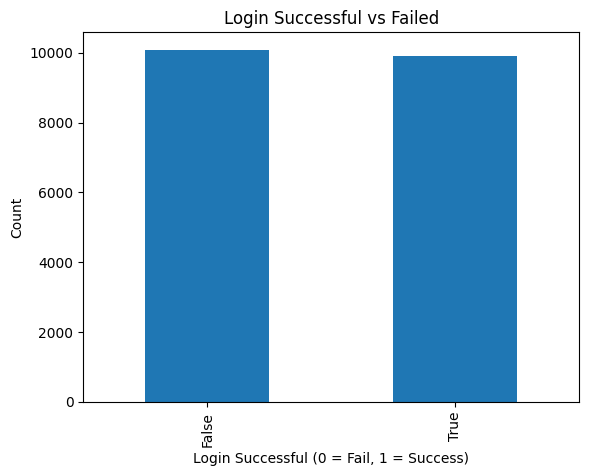

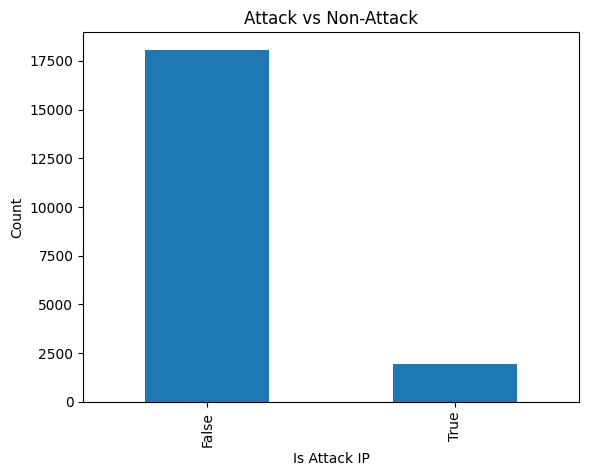

/tmp/ipython-input-4232091168.py:16: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df.groupby(df["Login Timestamp"].dt.floor("T"))


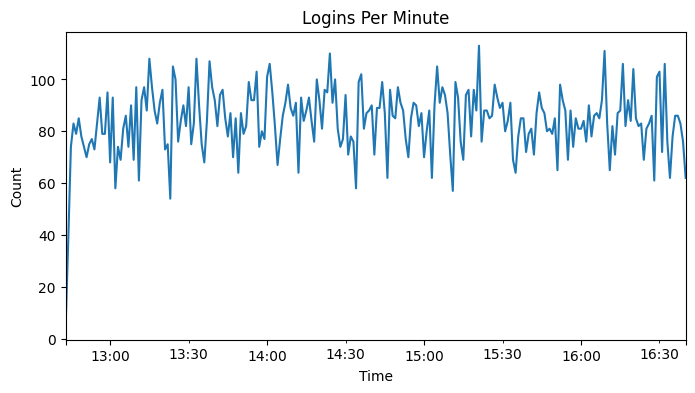

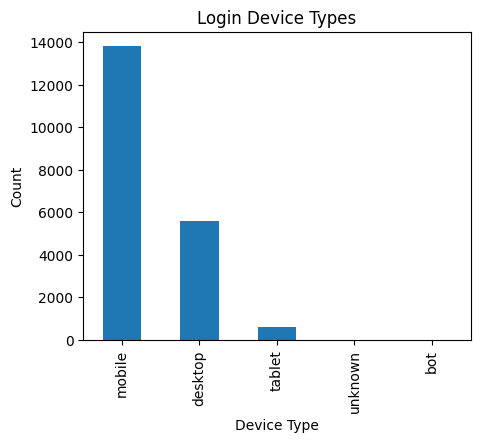

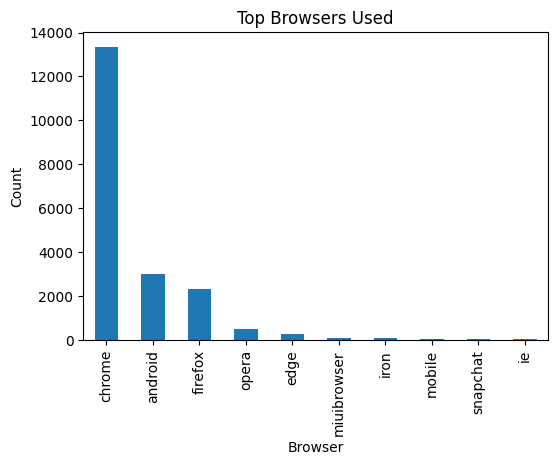

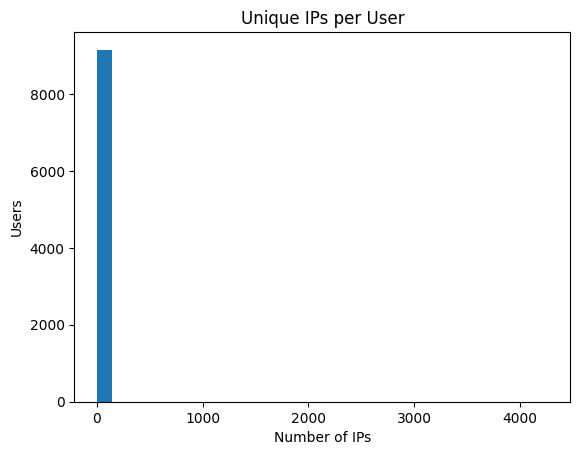

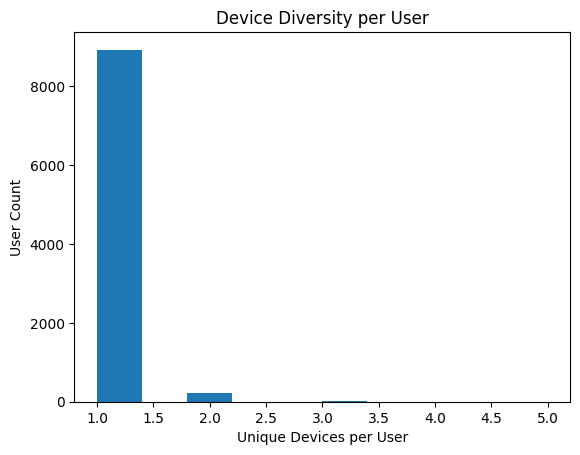

In [319]:
import matplotlib.pyplot as plt

df["Login Successful"].value_counts().plot(kind="bar")
plt.title("Login Successful vs Failed")
plt.xlabel("Login Successful (0 = Fail, 1 = Success)")
plt.ylabel("Count")
plt.show()

df["Is Attack IP"].value_counts().plot(kind="bar")
plt.title("Attack vs Non-Attack")
plt.xlabel("Is Attack IP")
plt.ylabel("Count")
plt.show()

logins_per_min = (
    df.groupby(df["Login Timestamp"].dt.floor("T"))
      .size()
)

logins_per_min.plot(figsize=(8,4))
plt.title("Logins Per Minute")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()

df["Device Type"].value_counts().plot(kind="bar", figsize=(5,4))
plt.title("Login Device Types")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

df["browser"].value_counts().head(10).plot(kind="bar", figsize=(6,4))
plt.title("Top Browsers Used")
plt.xlabel("Browser")
plt.ylabel("Count")
plt.show()

ip_counts = df.groupby("User ID")["IP Address"].nunique()

plt.hist(ip_counts, bins=30)
plt.title("Unique IPs per User")
plt.xlabel("Number of IPs")
plt.ylabel("Users")
plt.show()

device_per_user = df.groupby("User ID")["Device Type"].nunique()

plt.hist(device_per_user, bins=10)
plt.title("Device Diversity per User")
plt.xlabel("Unique Devices per User")
plt.ylabel("User Count")
plt.show()
